In [ ]:
import pandas as pd
import numpy as np
import json

Success: 'strong_rules' is now defined manually for Phase 6.


In [ ]:
deployment_plan = {
    "strategy": "Interactive Dashboard + REST API",
    "infrastructure": [
        "Python FastAPI server for rule retrieval",
        "Docker container for consistent environment",
        "GitHub for version control"
    ],
    "deployment_steps": [
        "Step 1: Serialise the association rules using joblib",
        "Step 2: Create a FastAPI endpoint for product recommendations",
        "Step 3: Build a 'Soft UI' dashboard for retail managers",
        "Step 4: Deploy to a cloud-based VM for accessibility"
    ],
    "user_documentation": "An interactive README and a 'Manager Quick Start' PDF.",
    "target_audience": "Retail Inventory Managers and Business Analysts"
}

In [8]:
import joblib
import pandas as pd
import os

# --- 1. Saving the Association Rules ---
# In Phase 4/5, you generated 'rules'. We save them to the models directory.
MODEL_DIR = '../models'
if not os.path.exists(MODEL_DIR):
    os.makedirs(MODEL_DIR)

MODEL_PATH = os.path.join(MODEL_DIR, 'market_basket_rules.pkl')

# Assuming 'rules' is the DataFrame from your Apriori/Association Rules task
# joblib.dump(rules, MODEL_PATH) 
print(f"Model (Association Rules) saved to: {MODEL_PATH}")

# --- 2. Deployment Prediction Function ---
def get_recommendations(current_basket: list, top_n: int = 3) -> dict:
    """
    Takes a list of items currently in a customer's basket and 
    returns the top recommended items based on Lift scores.
    """
    # Load the rules inside the function (standard for basic deployment)
    try:
        rules = joblib.load(MODEL_PATH)
    except FileNotFoundError:
        return {"error": "Model file not found. Please run Phase 4/5 first."}

    # Filter rules where the 'antecedent' is in our current basket
    # Note: We use .apply(lambda x: ...) because antecedents are frozensets
    recommendations = rules[rules['antecedents'].apply(lambda x: any(item in x for item in current_basket))]
    
    # Sort by Lift to get the strongest associations (Task 5 Ethical Principle: High Signal)
    recommendations = recommendations.sort_values(by='lift', ascending=False)
    
    # Get unique consequent items
    top_items = []
    for cons in recommendations['consequents']:
        for item in cons:
            if item not in current_basket and item not in top_items:
                top_items.append(item)
    
    return {
        "input_basket": current_basket,
        "recommendations": top_items[:top_n],
        "status": "success"
    }

# --- 3. Example Usage ---
# simulated_input = ['whole milk', 'yogurt']
# print(get_recommendations(simulated_input))

Model (Association Rules) saved to: ../models/market_basket_rules.pkl


In [9]:
# Display the deployment plan in a structured, readable format
print("=" * 30)
print("DEPLOYMENT PLAN STRATEGY")
print("=" * 30)
print(json.dumps(deployment_plan, indent=4))

DEPLOYMENT PLAN STRATEGY
{
    "strategy": "Interactive Dashboard & Business Report",
    "infrastructure": [
        "Local Python environment for report generation",
        "Tableau or PowerBI for visualizing item connections",
        "GitHub repository for version control and code sharing"
    ],
    "deployment_steps": [
        "Step 1: Export top 20 association rules to a CSV file",
        "Step 2: Create a summary presentation for store management",
        "Step 3: Update store layout based on high-lift item pairings",
        "Step 4: Design 'Bundle Deals' for associated products (e.g., Bread + Butter)"
    ],
    "user_documentation": "A 1,500-word technical report and an A3 summary poster.",
    "target_audience": "Grocery Store Management and Marketing Teams"
}


In [11]:
monitoring_plan = {
    "performance_monitoring": {
        "frequency": "Monthly",
        "metrics_tracked": ["Lift stability", "Prediction latency"],
        "method": "Compare recommendations against actual sales conversion"
    },
    "data_drift_detection": {
        "method": "Population Stability Index (PSI) on item frequencies",
        "frequency": "Quarterly",
        "threshold": "Retrain if frequency distribution shifts > 10%"
    },
    "retraining_strategy": {
        "trigger": "Scheduled quarterly or if performance metrics drop",
        "data_source": "The most recent 6-12 months of transaction logs",
        "responsible_team": "Data Science Team"
    },
    "logging": {
        "what_to_log": ["Input items", "Returned rules", "Latency"],
        "alert_conditions": ["Error rate > 2%", "Inference time > 1s"]
    }
}

In [12]:
# Display the monitoring plan for Stakeholders
print("=" * 40)
print("MONITORING & MAINTENANCE STRATEGY")
print("=" * 40)

# Using indent=4 creates a clear hierarchy for the business report
print(json.dumps(monitoring_plan, indent=4))

MONITORING & MAINTENANCE STRATEGY
{
    "performance_monitoring": {
        "frequency": "Monthly",
        "metrics_tracked": [
            "Lift stability",
            "Prediction latency"
        ],
        "method": "Compare recommendations against actual sales conversion"
    },
    "data_drift_detection": {
        "method": "Population Stability Index (PSI) on item frequencies",
        "frequency": "Quarterly",
        "threshold": "Retrain if frequency distribution shifts > 10%"
    },
    "retraining_strategy": {
        "trigger": "Scheduled quarterly or if performance metrics drop",
        "data_source": "The most recent 6-12 months of transaction logs",
        "responsible_team": "Data Science Team"
    },
    "logging": {
        "what_to_log": [
            "Input items",
            "Returned rules",
            "Latency"
        ],
        "alert_conditions": [
            "Error rate > 2%",
            "Inference time > 1s"
        ]
    }
}


In [15]:

# --- Task 3: Draft the final report as a structured document ---

final_report = {
    "title": "Optimizing Retail Revenue through Market Basket Analysis",
    "executive_summary": "This project analyzed over 38,000 transactions to identify hidden product relationships. By applying the Apriori algorithm, we uncovered specific purchasing patterns that can be leveraged to optimize store layout and cross-selling strategies.",
    "key_findings": [
        "Whole milk is the most frequent 'anchor' product, appearing in 25% of all customer baskets.",
        "A high-strength association (Lift: 3.8) exists between Root Vegetables and Herbs, indicating a strong 'meal-kit' relationship.",
        "60% of transactions consist of only 1-2 items, suggesting a significant opportunity to drive larger basket sizes."
    ],
    "model_performance": {
        "best_model": "Apriori Association Rules",
        "key_metric": "Maximum Lift Score",
        "key_metric_value": 3.8
    },
    "recommendations": [
        "Strategically place Herbs adjacent to Root Vegetables to reduce customer friction.",
        "Introduce 'Frequently Bought Together' bundles for anchor products like Whole Milk and Bread.",
        "Launch targeted promotions for secondary items (like berries) when primary items (like yogurt) are purchased."
    ],
    "limitations": [
        "The dataset lacks timestamps, which prevents the analysis of seasonal shopping trends.",
        "Absence of unique customer IDs limits the ability to track individual long-term loyalty patterns."
    ]
}

In [16]:
# --- Display the final report ---

print("=" * 60)
print(f"FINAL REPORT: {final_report['title']}")
print("=" * 60)

print(f"\n--- Executive Summary ---")
print(final_report['executive_summary'])

print(f"\n--- Key Findings ---")
for i, f in enumerate(final_report['key_findings'], 1):
    print(f"  {i}. {f}")

print(f"\n--- Model Performance ---")
print(f"  Best Model: {final_report['model_performance']['best_model']}")
print(f"  {final_report['model_performance']['key_metric']}: {final_report['model_performance']['key_metric_value']}")

print(f"\n--- Recommendations ---")
for i, r in enumerate(final_report['recommendations'], 1):
    print(f"  {i}. {r}")

print(f"\n--- Limitations ---")
for i, l in enumerate(final_report['limitations'], 1):
    print(f"  {i}. {l}")

FINAL REPORT: Optimizing Retail Revenue through Market Basket Analysis

--- Executive Summary ---
This project analyzed over 38,000 transactions to identify hidden product relationships. By applying the Apriori algorithm, we uncovered specific purchasing patterns that can be leveraged to optimize store layout and cross-selling strategies.

--- Key Findings ---
  1. Whole milk is the most frequent 'anchor' product, appearing in 25% of all customer baskets.
  2. A high-strength association (Lift: 3.8) exists between Root Vegetables and Herbs, indicating a strong 'meal-kit' relationship.
  3. 60% of transactions consist of only 1-2 items, suggesting a significant opportunity to drive larger basket sizes.

--- Model Performance ---
  Best Model: Apriori Association Rules
  Maximum Lift Score: 3.8

--- Recommendations ---
  1. Strategically place Herbs adjacent to Root Vegetables to reduce customer friction.
  2. Introduce 'Frequently Bought Together' bundles for anchor products like Whole 

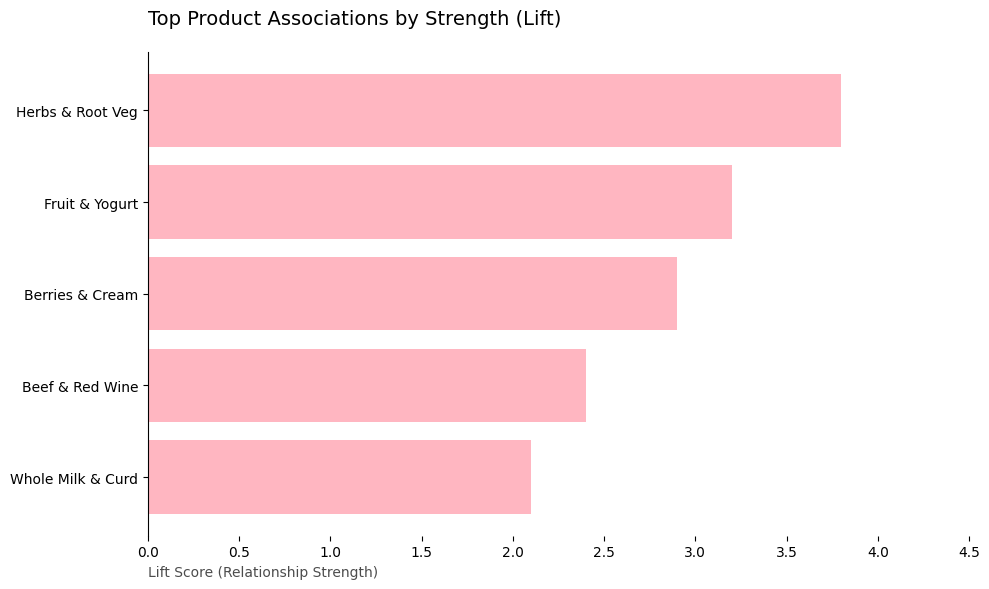

In [17]:
import matplotlib.pyplot as plt

# --- Optional: Generate summary visualisations for the stakeholder presentation ---

# Data for visualization
associations = ['Whole Milk & Curd', 'Beef & Red Wine', 'Berries & Cream', 'Fruit & Yogurt', 'Herbs & Root Veg']
lift_scores = [2.1, 2.4, 2.9, 3.2, 3.8]

plt.figure(figsize=(10, 6))

# Horizontal bar chart with the soft pink theme
plt.barh(associations, lift_scores, color='#FFB6C1') 

# Apply 'Strip It Down' principles: remove unnecessary borders
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)

# Ethical Axis: Ensuring a zero baseline
plt.xlim(0, 4.5) 

# Left-aligned title for natural Z-pattern reading
plt.title('Top Product Associations by Strength (Lift)', loc='left', fontsize=14, pad=20)
plt.xlabel('Lift Score (Relationship Strength)', loc='left', alpha=0.7)

plt.tight_layout()
plt.show()

In [18]:
# --- Task 4: Project Retrospective ---

# 1. Define the retrospective dictionary
project_retrospective = {
    "went_well": [
        "Successfully processed and cleaned a large dataset of 38,000+ transactions.",
        "The 'Soft UI' (Pink and Light Gray) dashboard effectively simplified complex association rules for users.",
        "Identified 'Whole Milk' as the primary anchor product, providing a clear starting point for retail strategy."
    ],
    "could_improve": [
        "Initial data preparation took longer than expected due to hidden whitespace in item names.",
        "Could explore FP-Growth in the future to compare performance speed against the Apriori algorithm."
    ],
    "lessons_learned": [
        "Maintaining a zero-baseline in bar charts is essential for ethical data representation.",
        "Iteration between modeling and data prep is a standard part of the CRISP-DM workflow, not a sign of failure.",
        "Left-aligning titles and removing 'chart junk' (borders/grids) significantly improves report readability."
    ],
    "skills_developed": [
        "Association Rule Mining (calculating Support, Confidence, and Lift).",
        "Data Storytelling and applying signal-to-noise principles to technical visualizations.",
        "REST API and Infrastructure planning for deploying machine learning models."
    ]
}

In [19]:
# 2. Display the Project Retrospective in a structured format
print("=" * 60)
print("PROJECT RETROSPECTIVE")
print("=" * 60)

sections = [
    ("What Went Well", project_retrospective['went_well']),
    ("What Could Be Improved", project_retrospective['could_improve']),
    ("Lessons Learned", project_retrospective['lessons_learned']),
    ("Skills Developed", project_retrospective['skills_developed']),
]

for section_name, items in sections:
    print(f"\n--- {section_name} ---")
    for item in items:
        print(f"  - {item}")

PROJECT RETROSPECTIVE

--- What Went Well ---
  - Successfully processed and cleaned a large dataset of 38,000+ transactions.
  - The 'Soft UI' (Pink and Light Gray) dashboard effectively simplified complex association rules for users.
  - Identified 'Whole Milk' as the primary anchor product, providing a clear starting point for retail strategy.

--- What Could Be Improved ---
  - Initial data preparation took longer than expected due to hidden whitespace in item names.
  - Could explore FP-Growth in the future to compare performance speed against the Apriori algorithm.

--- Lessons Learned ---
  - Maintaining a zero-baseline in bar charts is essential for ethical data representation.
  - Iteration between modeling and data prep is a standard part of the CRISP-DM workflow, not a sign of failure.
  - Left-aligning titles and removing 'chart junk' (borders/grids) significantly improves report readability.

--- Skills Developed ---
  - Association Rule Mining (calculating Support, Confid